<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1: Linear Regression

## Linear Regression with 1 Var

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Problem Statement

As in the lecture, you will use the motivating example of housing price prediction.  
This lab will use a simple data set with only two data points - a house with 1000 square feet(sqft) sold for \\$300,000 and a house with 2000 square feet sold for \\$500,000. These two points will constitute our *data or training set*. In this lab, the units of size are 1000 sqft and the units of price are 1000s of dollars.

| Size (1000 sqft)     | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1.0               | 300                      |
| 2.0               | 500                      |

You would like to fit a linear regression model (shown above as the blue straight line) through these two points, so you can then predict price for other houses - say, a house with 1200 sqft.


In [ ]:
x_train=np.array([1.0,2.0])
y_train=np.array([300.0, 500.0])
# x_train -> input var, size in 1000 sqfft
# y_train -> traget, price in $1000
print(f"x_train={x_train}")
print(f"y_train={y_train}")

x_train=[1. 2.]
y_train=[300. 500.]


In [ ]:
m=x_train.shape[0]
# m -> number of training examples, shape gives row, col -> we need row
print(f"Number of trianing examples: {m}")

Number of trianing examples: 2


In [ ]:
# showing the trianing exmaples as ( , )
for i in range(2):
    print(f"i = {i}")
    x_i=x_train[i]
    y_i=y_train[i]
    print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

i = 0
(x^(0), y^(0)) = (1.0, 300.0)
i = 1
(x^(1), y^(1)) = (2.0, 500.0)


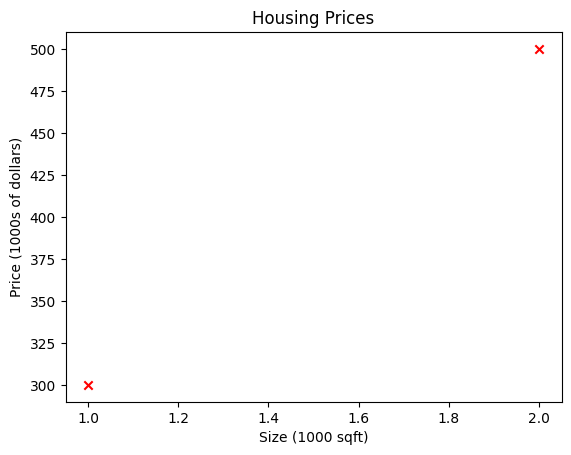

In [ ]:
# plotting data
plt.scatter(x_train,y_train, marker='x', c='r')
plt.title('Housing Prices')
plt.xlabel('Size (1000 sqft)')
plt.ylabel('Price (1000s of dollars)')
plt.show()

As described in lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is represented as

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

The formula above is how you can represent straight lines - different values of $w$ and $b$ give you different straight lines on the plot. <br/> <br/> <br/> <br/> <br/>

Let's try to get a better intuition for this through the code blocks below. Let's start with $w = 100$ and $b = 100$.

In [ ]:
w=100
b=100
print(f"w = {w}")
print(f"b = {b}")

w = 100
b = 100


In [ ]:
def compute_model_output(x,w,b):
    """
    x : Data, m exmaples
    w,b : model parameters
    w -> slope, b -> bias
    """
    m=x.shape[0]
    f_wb=np.zeros(m)
    for i in range(m):
        f_wb[i]=w*x[i]+b
    return f_wb

Text(0, 0.5, 'Price (1000s of dollars)')

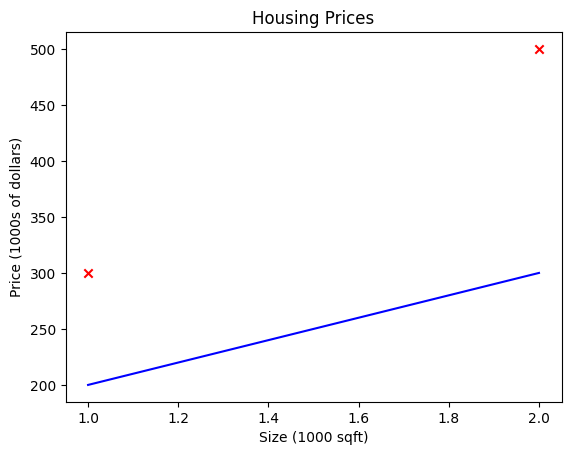

In [ ]:
# temp_f_wb -> y hat
temp_f_wb=compute_model_output(x_train,w,b)

#plot prediction
plt.plot(x_train, temp_f_wb, c='b', label='Prediction')
# plot data points
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')
plt.title("Housing Prices")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")

setting  𝑤=100
  and  𝑏=100
  does not result in a line that fits our data.

In [ ]:
def plot_linear_regression_model(y_hat, x_train, colour):
    temp_f_wb=y_hat
    plt.plot(x_train, temp_f_wb, c=colour, label='Prediction')
    # plot data points
    plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')
    plt.title("Housing Prices")
    plt.xlabel("Size (1000 sqft)")
    plt.ylabel("Price (1000s of dollars)")

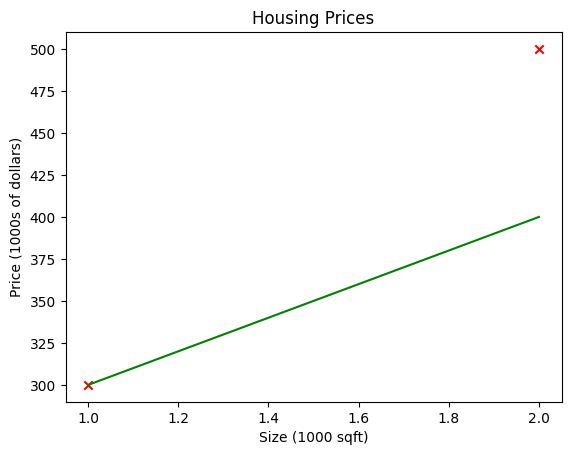

In [ ]:
plot_linear_regression_model(compute_model_output(x_train, 100, 200), x_train,'g')

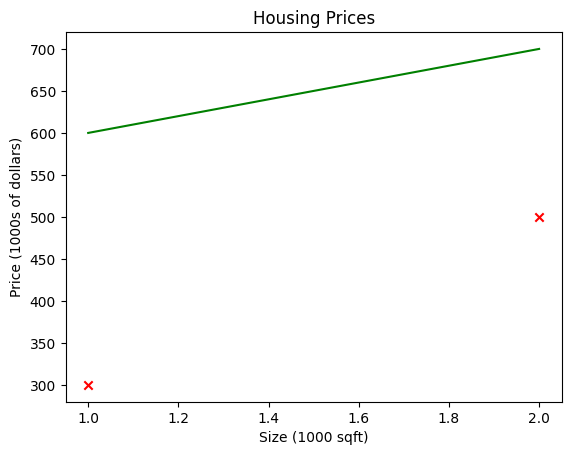

In [ ]:
plot_linear_regression_model(compute_model_output(x_train, 100, 500), x_train,'g')

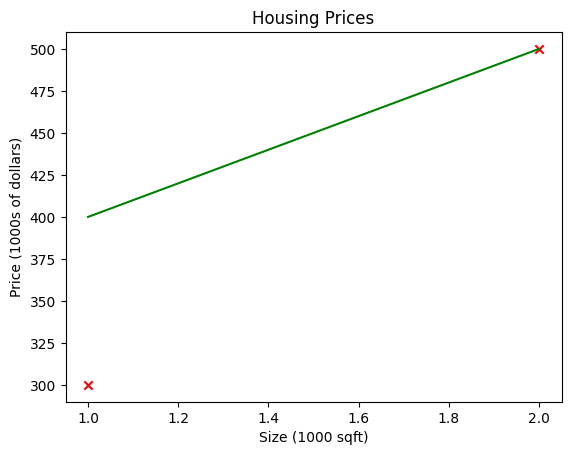

In [ ]:
plot_linear_regression_model(compute_model_output(x_train, 100, 300), x_train,'g')

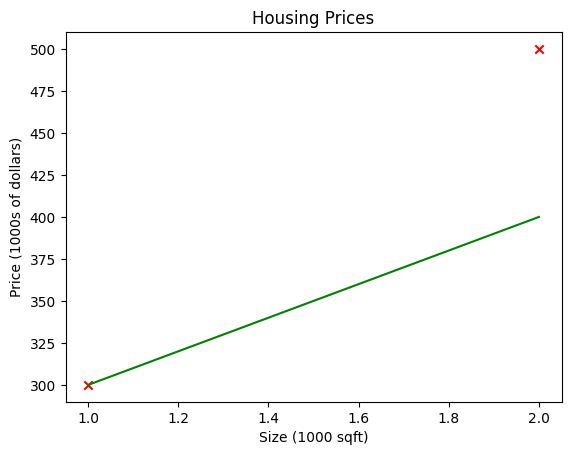

In [ ]:
plot_linear_regression_model(compute_model_output(x_train, 100, 200), x_train,'g')

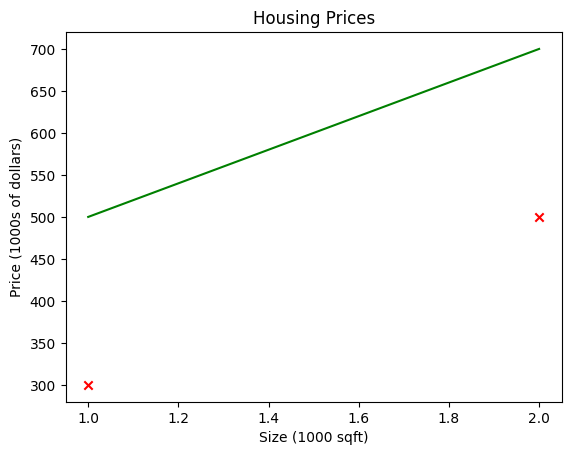

In [ ]:
plot_linear_regression_model(compute_model_output(x_train, 200, 300), x_train,'g')

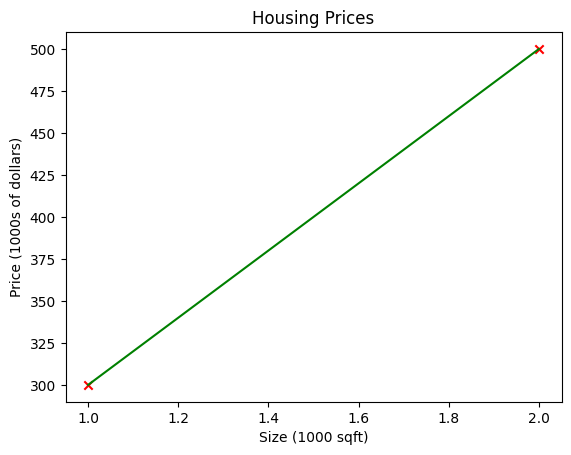

In [ ]:
plot_linear_regression_model(compute_model_output(x_train, 200, 100), x_train,'g')

In [ ]:
size_of_house=float(input("Enter size of house: "))
x_input=np.array([size_of_house])
price_of_house=compute_model_output(x_input,w=200, b=100)
print(f"Your hourse val is {price_of_house[0]:0.2f}")

# Cost Func

For a small number of data points, we can visually estimate a line that fits the data. However, with a large number of inputs (and possibly noisy data), it becomes impossible to manually find the best-fitting line.

Therefore, we define a cost function, which measures how far the model’s predictions are from the actual values. In linear regression, this is typically the mean squared error, i.e., the average of the squared differences between predicted and actual values.

The goal of machine learning is to find parameters (w, b) that minimize this cost, resulting in the best possible fit to the data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x_train = np.array([1.0, 2.0])           #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])           #(price in 1000s of dollars)

# f_wb -> y hat

In [ ]:
def compute_cost(x,y,w,b):
    """
    Computes the cost func for linear regression.
    Args:
        x (ndarray (m,)): Data, inputs/training set
        y (ndarray (m,)): target values
        w,b (scalar)    : model parameters
    Returns total_cost(float): The cost of using w,b as the parameter to find the data points in x and y
    """
    m=x.shape[0] # numb of training examples

    cost_sum=0
    for i in range(m):
        f_wb=w*x[i]+b
        cost=(f_wb-y[i])**2
        cost_sum=cost_sum+cost
    total_cost=(1/(2*m))*cost_sum
    return total_cost


In [ ]:
# larger dataset

In [ ]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

In [ ]:
w = int(input("Enter a val for w (int): "))
b = int(input("Enter a val for b (int): "))
print(f"Cost for w = {w} and b = {b} is:  {compute_cost(x_train,y_train, w,b)}")

# Gradient Descent

Enough with manaully guessing each vals for w and b. Time to automate it with gradient descent.

It will work like this:


$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

In [ ]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
# Load our data set
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0])   #target value

In [ ]:
def compute_cost(x,y,w,b):
    """
    Computes the cost func for linear regression.
    Args:
        x (ndarray (m,)): Data, inputs/training set
        y (ndarray (m,)): target values
        w,b (scalar)    : model parameters
    Returns total_cost(float): The cost of using w,b as the parameter to find the data points in x and y
    """
    m=x.shape[0] # numb of training examples

    cost_sum=0
    for i in range(m):
        f_wb=w*x[i]+b
        cost=(f_wb-y[i])**2
        cost_sum=cost_sum+cost
    total_cost=(1/(2*m))*cost_sum
    return total_cost


In [ ]:
def compute_gradient(x,y,w,b):
    """
    Computes gradient for linear regression
    Args:
        x (ndarray (m,)): Data, m examples
        y (ndarray (m,)): target values (given)
        w,b (scalar)    : model parameters

    Returns:
        dj_dw (scalar): The gradient of the cost with respect to the parameters w
        dj_db (scalar): The gradient of the cost with respect to the parameter b
     """
     # number of trianing examples
    m=  x.shape[0]
    dj_dw=0.0
    dj_db=0.0
    for i in range(m):
        y_hat=w*x[i]+b
        dj_dw_i=(y_hat-y[i])*x[i] # error on w for ith training set
        dj_db_i=y_hat-y[i] # error on b for ith training set
        dj_dw+=dj_dw_i
        dj_db+=dj_db_i
    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_dw,dj_db

In [ ]:
def gradient_descent(x,y,w_in,b_in, alpha, num_of_iteration, cost_func,gradient_func):
    """
    Performs gradeint descent to fit w,b. Updates w,b by taking num_of_iterms gradeints steps with learning rate alpha
    Args:
        x -> ndarray : Data, trainign examples
        y -> ndarray : target vals
        w_in, b_in : initial val fo w and b
        alpha -> float : learning rate
        num_of_iteration -> int : number of times to run gradient descent
        cost_function -> func to call to produce cost
        gradient_function: func to call to produce gradient


        Return:
            w -> Update val of parameter after running gradient descent
            b -> Update val of parameter after running gradient descent
            J_history -> list of cost values
            p_history (list): History of parameters [w,b]
    """

    # arrays to store cost J and w at each iterations for graphing later

    J_history=[]
    p_history=[]
    b=b_in
    w=w_in
    for i in range(num_of_iteration):
        dj_dw, dj_db=gradient_func(x,y,w,b)
        b=b-alpha*dj_db
        w=w-alpha*dj_dw

        if i < 10000:
            J_history.append(cost_func(x,y,w,b))
            p_history.append([w,b])
        if i % math.ceil(num_of_iteration / 10) == 0:
            print(
                f"Iteration {i}: "
                f"Cost {J_history[-1]:.2e}, "
                f"dj_dw: {dj_dw:.3e}, dj_db: {dj_db:.3e}, "
                f"w: {w:.3e}, b: {b:.3e}"
            )
    return w, b, J_history, p_history

In [ ]:
# initializ paraments
w_init=0
b_init=0
interations=10000
temp_alpha=1.0e-2
w_final, b_final, J_history, p_history=gradient_descent(x_train,y_train,w_init, b_init, temp_alpha,interations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

### Cost versus iterations of gradient descent
A plot of cost versus iterations is a useful measure of progress in gradient descent. Cost should always decrease in successful runs. The change in cost is so rapid initially, it is useful to plot the initial decent on a different scale than the final descent. In the plots below, note the scale of cost on the axes and the iteration step.

In [ ]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_history[:100])
ax2.plot(1000 + np.arange(len(J_history[1000:])), J_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost');  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

### Predictions
Now that you have discovered the optimal values for the parameters $w$ and $b$, you can now use the model to predict housing values based on our learned parameters. As expected, the predicted values are nearly the same as the training values for the same housing. Further, the value not in the prediction is in line with the expected value.

In [ ]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

# Regression with Multiple features/inputs

# Multiple Variable Linear Regression

## 1.3 Notation
Here is a summary of some of the notation you will encounter, updated for multiple features.  

|: ------------|: ------------------------------------------------------------||
| $a$ | scalar, non bold                                                      ||
| $\mathbf{a}$ | vector, bold                                                 ||
| $\mathbf{A}$ | matrix, bold capital                                         ||
| **Regression** |         |    |     |
|  $\mathbf{X}$ | training example matrix                  | `X_train` |   
|  $\mathbf{y}$  | training example  targets                | `y_train`
|  $\mathbf{x}^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `X[i]`, `y[i]`|
| m | number of training examples | `m`|
| n | number of features in each example | `n`|
|  $\mathbf{w}$  |  parameter: weight,                       | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |     
| $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ | The result of the model evaluation at $\mathbf{x^{(i)}}$ parameterized by $\mathbf{w},b$: $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)}+b$  | `f_wb` |


## 2 Problem Statement

You will use the motivating example of housing price prediction. The training dataset contains three examples with four features (size, bedrooms, floors and, age) shown in the table below.  Note that, unlike the earlier labs, size is in sqft rather than 1000 sqft. This causes an issue, which you will solve in the next lab!

| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  

You will build a linear regression model using these values so you can then predict the price for other houses. For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.  


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

In [ ]:
x_train=np.array([[2104,5,1,45], [1416,3,2,40],[852,2,1,35]])
y_train=np.array([460,232,178])

### 2.1 Matrix X containing our examples
Similar to the table above, examples are stored in a NumPy matrix `X_train`. Each row of the matrix represents one example. When you have $m$ training examples ( $m$ is three in our example), and there are $n$ features (four in our example), $\mathbf{X}$ is a matrix with dimensions ($m$, $n$) (m rows, n columns).


$$\mathbf{X} =
\begin{pmatrix}
 x^{(0)}_0 & x^{(0)}_1 & \cdots & x^{(0)}_{n-1} \\
 x^{(1)}_0 & x^{(1)}_1 & \cdots & x^{(1)}_{n-1} \\
 \cdots \\
 x^{(m-1)}_0 & x^{(m-1)}_1 & \cdots & x^{(m-1)}_{n-1}
\end{pmatrix}
$$
notation:
- $\mathbf{x}^{(i)}$ is vector containing example i. $\mathbf{x}^{(i)}$ $ = (x^{(i)}_0, x^{(i)}_1, \cdots,x^{(i)}_{n-1})$
- $x^{(i)}_j$ is element j in example i. The superscript in parenthesis indicates the example number while the subscript represents an element.  

Display the input data.

In [ ]:
# data is stored in numpy array/ matrix

print(f"X shape: {x_train.shape}, x type: {type(x_train)}")
print(x_train)
print(f"y shape: {y_train.shape}, y type: {type(y_train)}")
print(y_train)

X shape: (3, 4), x type: <class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y shape: (3,), y type: <class 'numpy.ndarray'>
[460 232 178]


<a name="toc_15456_2.2"></a>
## 2.2 Parameter vector w, b

* $\mathbf{w}$ is a vector with $n$ elements.
  - Each element contains the parameter associated with one feature.
  - in our dataset, n is 4.
  - notionally, we draw this as a column vector

$$\mathbf{w} = \begin{pmatrix}
w_0 \\
w_1 \\
\cdots\\
w_{n-1}
\end{pmatrix}
$$
* $b$ is a scalar parameter.  

In [ ]:
b_init=785.62
w_init=np.array([0.391335,18.75376,-53.63,-26.42])
print(f"w_init shape: {w_init.shape}, w_init type: {type(w_init)}")
print(f"b_init type: {type(b_init)}")

w_init shape: (4,), w_init type: <class 'numpy.ndarray'>
b_init type: <class 'float'>


## 3 Model Prediction With Multiple Variables
The model's prediction with multiple variables is given by the linear model:

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$
where $\cdot$ is a vector `dot product`

To demonstrate the dot product, we will implement prediction using (1) and (2).

### 3.1 Single Prediction element by element
Our previous prediction multiplied one feature value by one parameter and added a bias parameter. A direct extension of our previous implementation of prediction to multiple features would be to implement (1) above using loop over each element, performing the multiply with its parameter and then adding the bias parameter at the end.


In [ ]:
def predict_single_loop(x,w,b):
    """
    Single predict using linear regression
    Args:
        x -> ndarray : shape (n,) with multiple features
        w -> ndarray : shape (n,) model parameters
        b -> scaler : model parameter
    Returns:
        p -> scalar : model prediction
    """

    n=x.shape[0]
    p=0
    for i in range(n):
        p_i=x[i]*w[i]
        p=p+p_i
    p=p+b
    return p

In [ ]:
# get a row from training data
x_vec=x_train[0:]
print(f"x_vec shape {x_vec.shape}, \nx_vec value: \n{x_vec}")

# make a prediction
y_hat=predict_single_loop(x_vec, w=w_init, b=b_init)
print(f"f_wb {y_hat.shape}, \nprediction: {y_hat}")

x_vec shape (3, 4), 
x_vec value: 
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
f_wb (4,), 
prediction: [-17528.45    736.58    769.89   -323.67]


Note the shape of `x_vec`. It is a 1-D NumPy vector with 4 elements, (4,). The result, `f_wb` is a scalar.

In [ ]:
# DIHN Ngy

## 4 Compute Cost With Multiple Variables
The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$


In contrast to previous labs, $\mathbf{w}$ and $\mathbf{x}^{(i)}$ are vectors rather than scalars supporting multiple features.

Below is an implementation of equations (3) and (4). Note that this uses a *standard pattern for this course* where a for loop over all `m` examples is used.

In [ ]:
def compute_cost(x,y,w,b):
    """
    Compute cost:
        Args:
            x -> ndarray (m,n) : Datam M examples with n features
            y -> ndarray (m,) : target vals
            w -> ndarray (n,) : model parameters
            b -> scalar : model parameter
        Returns:
            cost -> scalar : cost
    """
    m=x.shape[0]
    cost=0.0
    for i in range(m):
        y_hat_i=np.dot(x[i], w)+b
        cost=cost+(y_hat_i-y[i])**2

    cost=cost/(2*m)
    return cost

In [ ]:
cost=compute_cost(x_train, y_train, w_init, b_init)
print(f"Cost at optimal w: {cost}")

Cost at optimal w: 0.016726310466653054


## 5 Gradient Descent With Multiple Variables
Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


### 5.1 Compute Gradient with Multiple Variables
An implementation for calculating the equations (6) and (7) is below. There are many ways to implement this. In this version, there is an
- outer loop over all m examples.
    - $\frac{\partial J(\mathbf{w},b)}{\partial b}$ for the example can be computed directly and accumulated
    - in a second loop over all n features:
        - $\frac{\partial J(\mathbf{w},b)}{\partial w_j}$ is computed for each $w_j$.
   

In [ ]:
def compute_gradient(x,y,w,b):
    """
    Compiutes the gradeint for linear regression
    Args:
        x -> ndarray (m,n) : Data, m exmaples with n features
        y -> ndarray (m,) : target vals
        w -> ndarray (n,) : model parameters
        b -> scalar : model parameter
    Returns:
        dj_dw -> ndarray(n,) : The gradeints of the cost with rest to the parameters w
        dj_db -> scalar : The gradeint of the cost with respect to b
    """
    m, n = x.shape
    dj_dw=np.zeros((n,))
    dj_db=0

    for i in range(m):
        error=(np.dot(x[i], w)+b)-y[i]
        for j in range(n):
            dj_dw[j]=dj_dw[j]+error*x[i,j]
        dj_db=dj_db+error

    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_db, dj_db

In [ ]:
# compute and display gradient
temp_dj_db, temp_dj_dw=compute_gradient(x_train, y_train, w_init, b_init)
print(f"dj_db at initial w,b: {temp_dj_db}")
print(f"dj_dw at initial w,b: {temp_dj_dw}")

dj_db at initial w,b: 0.13140666666655912
dj_dw at initial w,b: 0.13140666666655912


### 5.2 Gradient Descent With Multiple Variables
The routine below implements equation (5) above.

In [ ]:
def gradient_descent(x,y,w_init, b_init, cost_function, gradient_function, alpha, num_of_iteration):
    """
    Performs batch gradeitn descent to learn w and b. updates w and b by taking number_of_iteration gradient steps with learning rate alpha
    Args:
        x -> ndarray(m,n): Data, m exmaples with n features
        y -> ndarray(m,): target vals
        w_init -> ndarrary(n,): initial model parameter
        b_init -> scaler: initial model parameter
        cost_function: function to call to compute the cost
        gradient_function: function to call to compute the gradient
        alpha -> float : learning rate
        num_of_iteration -> int : number of iterations to run gradeint descent

    Returns:
        w -> narray(n,) : updated vals of parameters
        b -> scaler : updated val of parameter

    """

    # an array to store cost J and W at each iteration
    # u can use it for graphing

    J_history=[]
    w=copy.deepcopy(w_init)
    b=b_init

    for i in range(num_of_iteration):
        # calc gradeitn descent and update paramenters
        dj_db,dj_dw=gradient_function(x, y, w, b)

        # udpate pamars using w, b, alpha, gradient
        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        # save cost J at each iterations
        if i < 10000:
            J_history.append(cost_function(x,y, w,b))

        # print cost every interval 10 times or as many itenrations
        if i% math.ceil(num_of_iteration / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
    return w,b,J_history # return final w,b,J history for graphing

In [ ]:
import copy
initial_w=np.zeros_like(w_init)
initial_b=0

iterations=1000
alpha=5.0e-7

w_final, b_final, J_history = gradient_descent(x_train, y_train, w_init, b_init, compute_cost, compute_gradient, alpha, iterations)

print(f"b,w found by gradient descent: {b_final:0.2f}, {w_final}")

m,_=x_train.shape
for i in range(m):
    print(f"Prediction : {np.dot(x_train[i], w_final)+ b_final:0.2f}, target val: {y_train[i]}")

Iteration    0: Cost     0.02   
Iteration  100: Cost     0.02   
Iteration  200: Cost     0.01   
Iteration  300: Cost     0.01   
Iteration  400: Cost     0.01   
Iteration  500: Cost     0.01   
Iteration  600: Cost     0.01   
Iteration  700: Cost     0.01   
Iteration  800: Cost     0.01   
Iteration  900: Cost     0.01   
b,w found by gradient descent: 785.62, [  0.39  18.75 -53.63 -26.42]
Prediction : 460.13, target val: 460
Prediction : 231.88, target val: 232
Prediction : 178.17, target val: 178


## Feature scaling and Learning Rate (Multi-variable)

## Goals
In this lab you will:
- Utilize  the multiple variables routines developed in the previous lab
- run Gradient Descent on a data set with multiple features
- explore the impact of the *learning rate alpha* on gradient descent
- improve performance of gradient descent by *feature scaling* using z-score normalization


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)


##  Problem Statement

As in the previous labs, you will use the motivating example of housing price prediction. The training data set contains many examples with 4 features (size, bedrooms, floors and age) shown in the table below. Note, in this lab, the Size feature is in sqft while earlier labs utilized 1000 sqft.  This data set is larger than the previous lab.

We would like to build a linear regression model using these values so we can then predict the price for other houses - say, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.

###  Dataset:
| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|----------------------- |  
| 952             | 2                   | 1                | 65           | 271.5                  |  
| 1244            | 3                   | 2                | 64           | 232                    |  
| 1947            | 3                   | 2                | 17           | 509.8                  |  
| ...             | ...                 | ...              | ...          | ...                    |


In [ ]:
x_train = np.array([
    [952, 2, 1, 65],
    [1244, 3, 2, 64],
    [1947, 3, 2, 17]
])

# y_train: prices
y_train = np.array([
    271.5,
    232,
    509.8
])
X_features = ['size(sqft)','bedrooms','floors','age']

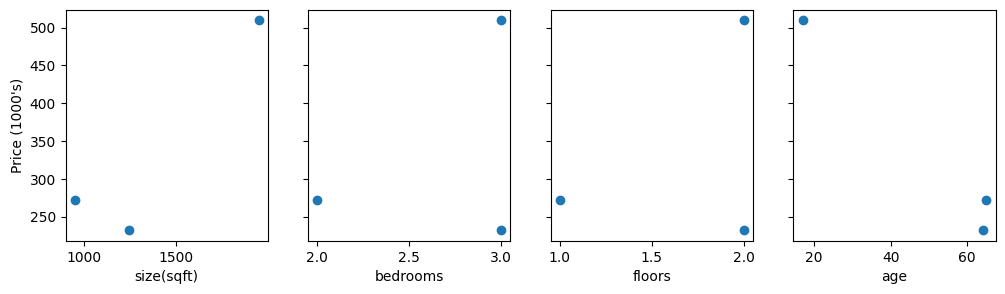

In [ ]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

Plotting each feature vs. the target, price, provides some indication of which features have the strongest influence on price. Above, increasing size also increases price. Bedrooms and floors don't seem to have a strong impact on price. Newer houses have higher prices than older houses.

<a name="toc_15456_5"></a>
## Gradient Descent With Multiple Variables
Here are the equations you developed in the last lab on gradient descent for multiple variables.:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j = 0..n-1}\newline
&b\ \ := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


## Learning Rate
<figure>
    <img src="./images/C1_W2_Lab06_learningrate.PNG" style="width:1200px;" >
</figure>
The lectures discussed some of the issues related to setting the learning rate $\alpha$. The learning rate controls the size of the update to the parameters. See equation (1) above. It is shared by all the parameters.  

Let's run gradient descent and try a few settings of $\alpha$ on our data set

## Feature Engineering and Polynomial Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

## Feature Engineering and Polynomial Regression Overview

Out of the box, linear regression provides a means of building models of the form:
$$f_{\mathbf{w},b} = w_0x_0 + w_1x_1+ ... + w_{n-1}x_{n-1} + b \tag{1}$$
What if your features/data are non-linear or are combinations of features? For example,  Housing prices do not tend to be linear with living area but penalize very small or very large houses resulting in the curves shown in the graphic above. How can we use the machinery of linear regression to fit this curve? Recall, the 'machinery' we have is the ability to modify the parameters $\mathbf{w}$, $\mathbf{b}$ in (1) to 'fit' the equation to the training data. However, no amount of adjusting of $\mathbf{w}$,$\mathbf{b}$ in (1) will achieve a fit to a non-linear curve.


### Polynomial Features

Above we were considering a scenario where the data was non-linear. Let's try using what we know so far to fit a non-linear curve. We'll start with a simple quadratic: $y = 1+x^2$

You're familiar with all the routines we're using. They are available in the lab_utils.py file for review. We'll use [`np.c_[..]`](https://numpy.org/doc/stable/reference/generated/numpy.c_.html) which is a NumPy routine to concatenate along the column boundary.

In [ ]:
x=np.arange(0,20,1)
y=1+x**2
X = x.reshape(-1,1)

In [ ]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2
X = x.reshape(-1, 1)

model_w,model_b = run_gradient_descent_feng(X,y,iterations=1000, alpha = 1e-2)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("no feature engineering")
plt.plot(x,X@model_w + model_b, label="Predicted Value");  plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.show()|

SyntaxError: invalid syntax (23235731.py, line 9)

In [ ]:
# create target data
x = np.arange(0, 20, 1)
y = 1 + x**2

# Engineer features
X = x**2      #<-- added engineered feature

In [ ]:
X = X.reshape(-1, 1)  #X should be a 2-D Matrix
model_w,model_b = run_gradient_descent_feng(X, y, iterations=10000, alpha = 1e-5)

plt.scatter(x, y, marker='x', c='r', label="Actual Value"); plt.title("Added x**2 feature")
plt.plot(x, np.dot(X,model_w) + model_b, label="Predicted Value"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

NameError: name 'run_gradient_descent_feng' is not defined